In [1]:
!git clone https://github.com/pyther-hub/ml4sci-taylor-series-task.git

Cloning into 'ml4sci-taylor-series-task'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 77 (delta 39), reused 58 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (77/77), 351.74 KiB | 6.17 MiB/s, done.
Resolving deltas: 100% (39/39), done.


In [2]:
%cd /kaggle/working/ml4sci-taylor-series-task

/kaggle/working/ml4sci-taylor-series-task


In [3]:
"""
main.py
==================
Training entry point for the unified Taylor coefficient prediction pipeline.

The model predicts ALL five Taylor coefficients in a single pass, using
<BREAK> tokens to delimit individual coefficients in the output sequence.

Training loop only computes teacher-forced val loss (fast).  After training,
loads best checkpoint, runs greedy decoding, and computes full accuracy metrics.

Usage
-----
python main.py

Edit the hyperparameters in the config section below.
"""

from __future__ import annotations

import os
import time
from typing import Dict

import torch
import torch.nn as nn

from dataset import BREAK_ID, EOS_ID, N_COEFFS, PAD_ID, SOS_ID, VOCAB_SIZE, decode, encode
from model import CoeffPredLSTM, CoeffPredTransformer
from train_validate import (
    build_dataloaders,
    get_device,
    print_epoch,
    set_seed,
    train_epoch,
    validate,
)

# ── Evaluation helpers ────────────────────────────────────────────────────
import sympy as sp
from dataset_generation import (
    _expr_to_prefix_tokens,
    compute_taylor_coefficients,
    prefix_tokens_to_infix,
)
from metrics import split_segments, per_segment_metrics

from report_logger import ReportLogger, sympy_equiv



In [4]:

# ══════════════════════════════════════════════════════════════════════════════
# CUSTOM TEST FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

CUSTOM_TEST_FUNCTIONS = [
    "(x**2 + 1)*sin(x)",
    "x**3*cos(2*x)",
    "exp(x)*(1 + x)",
    "x*exp(2*x)",
    "(1 + x**2)*exp(-x)",
    "exp(x)*sin(x)",
    "log(1 + x)",
    "log(1 + x**2)",
    "x*log(1 + x)",
    "x/(1 - x)",
    "x/(1 + x)",
    "1/(1 + x**2)",
    "x**2/(1 - x)",
    "sin(x**2)",
    "exp(x**2)",
    "cos(sqrt(1 + x))",
    "log(1 + sin(x))",
    "(x + 1)*exp(x)",
    "x**2*log(1 + x)",
    "exp(x)*cos(x)",
    "exp(x)*(x**2 + 1)",
    "sin(x)*cos(x)",
    "log(1 + x**3)",
    "log(1 + x)*cos(x)",
    "x*exp(x)*sin(x)",
    "x*exp(x)*cos(x)",
    "sqrt(1 + x)*sin(x)",
    "sqrt(1 + x)/(1 + x)",
    "cos(x)/(1 + x)",
    "exp(x)/(1 + x)",
]

TAYLOR_ORDER = N_COEFFS - 1   # 4 → coefficients c0 … c4
x_sym        = sp.Symbol("x")


# ══════════════════════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════════════════════

MODEL_CLASSES = {
    "transformer": CoeffPredTransformer,
    "lstm":        CoeffPredLSTM,
}

def build_model(model_type: str, config: Dict) -> nn.Module:
    """Instantiate the correct model class from model_type and config dict."""
    cls = MODEL_CLASSES[model_type]
    return cls(**config)


def run_custom_test_functions(
    model:   nn.Module,
    device:  torch.device,
    logger:  ReportLogger | None = None,
    max_gen_len: int = 512,
) -> tuple[int, int, int]:
    """Run evaluation on CUSTOM_TEST_FUNCTIONS with exact-match + SymPy equivalence.

    Returns (n_exact_correct, n_sympy_correct, n_attempted).
    """
    n_fn_exact   = 0
    n_fn_sympy   = 0
    n_fn_attempted = 0

    model.eval()
    with torch.no_grad():
        for fn_idx, fn_str in enumerate(CUSTOM_TEST_FUNCTIONS, 1):
            # 1. Parse string → sympy
            try:
                expr = sp.sympify(fn_str, locals={"x": x_sym})
            except Exception as e:
                print(f"\n  [{fn_idx:2d}] {fn_str}")
                print(f"       PARSE ERROR: {e}")
                continue

            # 2. Ground-truth Taylor coefficients
            gt_coeffs = compute_taylor_coefficients(expr, TAYLOR_ORDER)
            if gt_coeffs is None:
                print(f"\n  [{fn_idx:2d}] {fn_str}")
                print(f"       COEFF ERROR: sympy timed out")
                continue

            gt_token_lists = [_expr_to_prefix_tokens(c) for c in gt_coeffs]

            # 3. Encode source sequence
            fn_prefix = _expr_to_prefix_tokens(expr)
            src_ids   = [SOS_ID] + encode(fn_prefix) + [EOS_ID]
            src       = torch.tensor([src_ids], dtype=torch.long).to(device)

            # 4. Autoregressive decoding
            pred_ids = model.generate(src, max_len=max_gen_len)

            # 5. Split prediction on <BREAK> into per-coefficient segments
            pred_segs = split_segments(pred_ids, BREAK_ID, EOS_ID, PAD_ID)

            # 6. Compare: exact match + SymPy equivalence
            n_fn_attempted += 1
            n_coeff_exact = 0
            n_coeff_sympy = 0
            coeff_results = []

            print(f"\n  [{fn_idx:2d}] f(x) = {fn_str}")
            for coeff_i in range(N_COEFFS):
                gt_toks   = gt_token_lists[coeff_i] if coeff_i < len(gt_token_lists) else []
                pred_toks = pred_segs[coeff_i]       if coeff_i < len(pred_segs)     else []

                gt_ids_enc = encode(gt_toks)
                exact_match = (gt_ids_enc == pred_toks)

                gt_infix   = prefix_tokens_to_infix(gt_toks)
                pred_infix = prefix_tokens_to_infix(decode(pred_toks, skip_special=False))

                # SymPy equivalence check
                pred_strs = decode(pred_toks, skip_special=False)
                gt_expr_i = gt_coeffs[coeff_i] if coeff_i < len(gt_coeffs) else sp.Integer(0)
                s_match = sympy_equiv(pred_strs, gt_expr_i)

                if exact_match:
                    n_coeff_exact += 1
                if s_match:
                    n_coeff_sympy += 1

                status_e = "OK" if exact_match else "--"
                status_s = "OK" if s_match else "--"
                print(
                    f"       c{coeff_i} [exact={status_e} sympy={status_s}]"
                    f"  gt={gt_infix}"
                    f"  pred={pred_infix}"
                )

                coeff_results.append({
                    "coeff_idx": coeff_i,
                    "gt_infix": gt_infix,
                    "pred_infix": pred_infix,
                    "exact_match": exact_match,
                    "sympy_match": s_match,
                })

            all_exact = (n_coeff_exact == N_COEFFS)
            all_sympy = (n_coeff_sympy == N_COEFFS)
            if all_exact:
                n_fn_exact += 1
            if all_sympy:
                n_fn_sympy += 1

            print(f"       => exact: {n_coeff_exact}/{N_COEFFS}  sympy: {n_coeff_sympy}/{N_COEFFS}")

            if logger is not None:
                logger.log_eval_function_result(fn_str, coeff_results, all_exact, all_sympy)

    if n_fn_attempted:
        print(f"\n  Result: exact={n_fn_exact}/{n_fn_attempted}"
              f" ({100*n_fn_exact/n_fn_attempted:.1f}%)"
              f"  sympy={n_fn_sympy}/{n_fn_attempted}"
              f" ({100*n_fn_sympy/n_fn_attempted:.1f}%)")

    return n_fn_exact, n_fn_sympy, n_fn_attempted


def save_checkpoint(
    model:      nn.Module,
    path:       str,
    epoch:      int,
    val_metrics: Dict,
    arch_cfg:   Dict,
    model_type: str,
) -> None:
    os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)
    torch.save(
        {
            "epoch":       epoch,
            "n_coeffs":    N_COEFFS,
            "val_loss":    val_metrics.get("val_loss", float("inf")),
            "model_state": model.state_dict(),
            "config":      arch_cfg,
            "model_type":  model_type,
        },
        path,
    )
    print(f"  [save] checkpoint → {path}  (epoch={epoch})")

In [5]:

# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════

# ── Demo mode (set True to run only 2 epochs for quick testing) ───────────
DEMO_RUN = False
DEMO_EPOCHS = 2

# ── Model selection ───────────────────────────────────────────────────────
# MODEL_TYPE = "lstm"  # "transformer" or "lstm"
MODEL_TYPE = "lstm"

TRANSFORMER_CONFIG = {
    "d_model": 256,
    "nhead": 8,
    "num_encoder_layers": 3,
    "num_decoder_layers": 8,
    "dim_feedforward": 256,
    "dropout": 0.1
}

LSTM_CONFIG = {
    "d_model": 256,
    "hidden_size": 256,
    "num_encoder_layers": 2,
    "num_decoder_layers": 4,
    "dropout": 0.1
}

# ── Paths ─────────────────────────────────────────────────────────────────
DATASET_JSON    = "/kaggle/input/datasets/tensorpanda231/taylor-series-dataset-simple/taylor_dataset_100k.json"
CHECKPOINT_DIR  = "checkpoints"
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, f"taylor_series_pred_{MODEL_TYPE}.pt")

# ── Data split ────────────────────────────────────────────────────────────
VAL_RATIO   = 0.10
RANDOM_SEED = 1326

# ── Training ──────────────────────────────────────────────────────────────
BATCH_SIZE  = 256
NUM_EPOCHS  = 30
LR          = 3e-4
CLIP_GRAD   = 1.0
NUM_WORKERS = 0
PATIENCE    = 10  # early stopping patience (epochs without val_loss improvement)

# ── Post-training evaluation ──────────────────────────────────────────────
MAX_GEN_LEN = 512          # max decode steps for post-training greedy eval
MAX_SEQ_LEN = 512

# ── Report output ────────────────────────────────────────────────────
OUTPUT_DIR = os.path.join("reports", f"{MODEL_TYPE}_{time.strftime('%Y%m%d_%H%M%S')}")

# ── Override epochs if demo mode ──────────────────────────────────────────
if DEMO_RUN:
    NUM_EPOCHS = DEMO_EPOCHS
    print(f"  ** DEMO MODE: training for {DEMO_EPOCHS} epochs only **")


# ══════════════════════════════════════════════════════════════════════════════
# SETUP
# ══════════════════════════════════════════════════════════════════════════════

set_seed(RANDOM_SEED)
device = get_device()
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("=" * 68)
print(f"  coeff_pred training — unified model ({N_COEFFS} coefficients)")
print(f"  device  : {device}")
print(f"  dataset : {DATASET_JSON}")
print(f"  model   : {MODEL_TYPE}")
print(f"  seed    : {RANDOM_SEED}")
print(f"  epochs  : {NUM_EPOCHS}  (patience={PATIENCE})")
print("=" * 68)


# ══════════════════════════════════════════════════════════════════════════════
# DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════

train_loader, val_loader, full_ds = build_dataloaders(
    DATASET_JSON, VAL_RATIO, RANDOM_SEED, BATCH_SIZE, NUM_WORKERS,
    max_seq_len=MAX_SEQ_LEN,
)
print(f"\n  Dataset  : {len(full_ds)} items  (skipped={full_ds.n_skipped})")
print(f"  Train    : {len(train_loader.dataset)}   Val : {len(val_loader.dataset)}\n")


# ══════════════════════════════════════════════════════════════════════════════
# MODEL INITIALIZATION
# ══════════════════════════════════════════════════════════════════════════════

arch_cfg = TRANSFORMER_CONFIG if MODEL_TYPE == "transformer" else LSTM_CONFIG
model    = build_model(MODEL_TYPE, arch_cfg).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Params   : {n_params:,}   VOCAB_SIZE={VOCAB_SIZE}\n")


# ══════════════════════════════════════════════════════════════════════════════
# REPORT LOGGER
# ══════════════════════════════════════════════════════════════════════════════

logger = ReportLogger(output_dir=OUTPUT_DIR)
logger.log_config({
    "model_type": MODEL_TYPE,
    **arch_cfg,
    "optimizer": "Adam",
    "lr": LR,
    "scheduler": "CosineAnnealingLR",
    "batch_size": BATCH_SIZE,
    "epochs": NUM_EPOCHS,
    "patience": PATIENCE,
    "gradient_clipping": CLIP_GRAD,
    "dataset_size": len(full_ds),
    "train_size": len(train_loader.dataset),
    "val_size": len(val_loader.dataset),
    "vocab_size": VOCAB_SIZE,
    "max_seq_len": MAX_SEQ_LEN,
    "n_params": n_params,
    "seed": RANDOM_SEED,
    "demo_run": DEMO_RUN,
})


# ══════════════════════════════════════════════════════════════════════════════
# OPTIMIZER / LOSS / SCHEDULER
# ══════════════════════════════════════════════════════════════════════════════

criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, reduction="mean")
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=LR * 1e-2,
)


  coeff_pred training — unified model (5 coefficients)
  device  : cuda
  dataset : /kaggle/input/datasets/tensorpanda231/taylor-series-dataset-simple/taylor_dataset_100k.json
  model   : lstm
  seed    : 1326
  epochs  : 30  (patience=10)

  Dataset  : 99443 items  (skipped=557)
  Train    : 89499   Val : 9944

  Params   : 5,726,208   VOCAB_SIZE=29



In [6]:

# ══════════════════════════════════════════════════════════════════════════════
# TRAINING LOOP (with early stopping)
# ══════════════════════════════════════════════════════════════════════════════

best_val_loss = float("inf")
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    t0      = time.perf_counter()
    train_m = train_epoch(model, train_loader, optimizer, criterion, device, CLIP_GRAD,
                          log_every=10 if epoch == 1 else 0)

    val_m   = validate(model, val_loader, criterion, device)
    scheduler.step()

    elapsed = time.perf_counter() - t0
    is_best = val_m["val_loss"] < best_val_loss

    # Save checkpoint every epoch (for post-training evaluation).
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"epoch_{epoch:03d}.pt")
    torch.save(
        {
            "epoch":       epoch,
            "model_state": model.state_dict(),
            "val_loss":    val_m["val_loss"],
            "n_coeffs":    N_COEFFS,
            "config":      arch_cfg,
            "model_type":  MODEL_TYPE,
        },
        ckpt_path,
    )

    if is_best:
        best_val_loss = val_m["val_loss"]
        patience_counter = 0
        save_checkpoint(model, CHECKPOINT_PATH, epoch, val_m, arch_cfg, MODEL_TYPE)
    else:
        patience_counter += 1

    print_epoch(epoch, NUM_EPOCHS, train_m, val_m, elapsed, is_best)

    logger.log_epoch(epoch, {
        "train_loss": train_m["train_loss"],
        "val_loss": val_m["val_loss"],
        "train_tok_acc": train_m["train_tok_acc"],
        "val_tok_acc": val_m["val_tok_acc"],
        "train_sent_acc": train_m["train_sent_acc"],
        "val_sent_acc": val_m["val_sent_acc"],
    })

    # Early stopping check
    if patience_counter >= PATIENCE:
        print(f"\n  Early stopping triggered at epoch {epoch} (no improvement for {PATIENCE} epochs)")
        break

print(f"\n  Training complete.  Best val loss: {best_val_loss:.6f}")
print(f"  Best checkpoint: {CHECKPOINT_PATH}")


    step   10/350  loss=3.2918  tok_acc=0.162  sent_acc=0.000  elapsed=25.3s  ETA ~14m18s
    step   20/350  loss=3.0590  tok_acc=0.177  sent_acc=0.000  elapsed=49.7s  ETA ~13m40s
    step   30/350  loss=2.9282  tok_acc=0.182  sent_acc=0.000  elapsed=74.5s  ETA ~13m14s
    step   40/350  loss=2.8512  tok_acc=0.186  sent_acc=0.000  elapsed=99.1s  ETA ~12m48s
    step   50/350  loss=2.8036  tok_acc=0.187  sent_acc=0.000  elapsed=124.0s  ETA ~12m23s
    step   60/350  loss=2.7695  tok_acc=0.188  sent_acc=0.000  elapsed=148.9s  ETA ~11m59s
    step   70/350  loss=2.7460  tok_acc=0.189  sent_acc=0.000  elapsed=173.6s  ETA ~11m34s
    step   80/350  loss=2.7278  tok_acc=0.190  sent_acc=0.000  elapsed=198.2s  ETA ~11m09s
    step   90/350  loss=2.7138  tok_acc=0.190  sent_acc=0.000  elapsed=222.7s  ETA ~10m43s
    step  100/350  loss=2.7010  tok_acc=0.190  sent_acc=0.000  elapsed=246.6s  ETA ~10m16s
    step  110/350  loss=2.6888  tok_acc=0.190  sent_acc=0.000  elapsed=270.7s  ETA ~9m50s
    

In [7]:

# ══════════════════════════════════════════════════════════════════════════════
# LOAD BEST MODEL
# ══════════════════════════════════════════════════════════════════════════════

print("\n  Loading best model for evaluation ...")
ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True)
model.load_state_dict(ckpt["model_state"])
model.eval()


# # ══════════════════════════════════════════════════════════════════════════════
# # SAMPLE PREDICTIONS
# # ══════════════════════════════════════════════════════════════════════════════

# print(f"\n  Example predictions (unified, greedy):")
# shown = 0
# with torch.no_grad():
#     for src, tgt, _, _ in val_loader:
#         src   = src.to(device)
#         preds = model.generate_batch(src, max_len=MAX_GEN_LEN)
#         for i in range(len(preds)):
#             if shown >= 4:
#                 break
#             src_tok  = decode(src[i].tolist())
#             tgt_tok  = decode(tgt[i].tolist(), skip_special=False)
#             pred_tok = decode([t for t in preds[i] if t != EOS_ID], skip_special=False)
#             print(f"  ── example {shown + 1} ──")
#             print(f"     src  : {src_tok}")
#             print(f"     tgt  : {tgt_tok}")
#             print(f"     pred : {pred_tok}")
#             print(f"     match: {'✓' if tgt_tok == pred_tok else '✗'}")
#             shown += 1
#         if shown >= 4:
#             break


  Loading best model for evaluation ...


CoeffPredLSTM(
  (embedding): Embedding(29, 256, padding_idx=0)
  (encoder): LSTM(256, 256, num_layers=2, batch_first=True, dropout=0.1, bidirectional=True)
  (h_proj): Linear(in_features=512, out_features=256, bias=True)
  (c_proj): Linear(in_features=512, out_features=256, bias=True)
  (attention): BahdanauAttention(
    (W_enc): Linear(in_features=512, out_features=256, bias=False)
    (W_dec): Linear(in_features=256, out_features=256, bias=False)
    (v): Linear(in_features=256, out_features=1, bias=False)
  )
  (decoder): LSTM(768, 256, num_layers=4, batch_first=True, dropout=0.1)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc_out): Linear(in_features=256, out_features=29, bias=False)
)

In [8]:

# ══════════════════════════════════════════════════════════════════════════════
# FULL VALIDATION SET EVALUATION (autoregressive)
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 68)
print("  Full validation set evaluation (autoregressive decoding)")
print("=" * 68)

all_pred_ids = []
all_tgt_ids  = []
pred_lengths = []
gt_lengths   = []
n_fn_level_correct = 0
n_fn_level_total   = 0

with torch.no_grad():
    for batch_idx, (src, tgt, _, _) in enumerate(val_loader):
        src = src.to(device)
        preds = model.generate_batch(src, max_len=MAX_GEN_LEN)

        for i in range(len(preds)):
            pred_seq = preds[i]
            tgt_seq  = tgt[i].tolist()

            # strip SOS from target for comparison
            tgt_stripped = [t for t in tgt_seq[1:] if t != PAD_ID]

            all_pred_ids.append(pred_seq)
            all_tgt_ids.append(tgt_stripped)

            # sequence lengths (up to EOS)
            pred_len = len(pred_seq)
            for pi, tid in enumerate(pred_seq):
                if tid == EOS_ID:
                    pred_len = pi
                    break
            gt_len = len(tgt_stripped)
            for gi, tid in enumerate(tgt_stripped):
                if tid == EOS_ID:
                    gt_len = gi
                    break
            pred_lengths.append(pred_len)
            gt_lengths.append(gt_len)

            # function-level accuracy: all segments must match exactly
            pred_segs = split_segments(pred_seq, BREAK_ID, EOS_ID, PAD_ID)
            tgt_segs  = split_segments(tgt_stripped, BREAK_ID, EOS_ID, PAD_ID)
            n_fn_level_total += 1
            if len(pred_segs) == len(tgt_segs) == N_COEFFS:
                if all(pred_segs[j] == tgt_segs[j] for j in range(N_COEFFS)):
                    n_fn_level_correct += 1

        if (batch_idx + 1) % 10 == 0:
            print(f"    batch {batch_idx + 1}/{len(val_loader)} ...")




  Full validation set evaluation (autoregressive decoding)
    batch 10/39 ...
    batch 20/39 ...
    batch 30/39 ...


In [9]:

# ══════════════════════════════════════════════════════════════════════════════
# COMPUTE METRICS
# ══════════════════════════════════════════════════════════════════════════════

# per-segment (per-coefficient) metrics
seg_metrics = per_segment_metrics(all_pred_ids, all_tgt_ids, PAD_ID, BREAK_ID, N_COEFFS)

# aggregate metrics across all coefficients
from metrics import token_accuracy, sentence_accuracy

# build padded tensors for aggregate token/sentence accuracy
max_pred = max((len(p) for p in all_pred_ids), default=1)
max_tgt  = max((len(t) for t in all_tgt_ids),  default=1)
L = max(max_pred, max_tgt)
N = len(all_pred_ids)
pred_tensor = torch.full((N, L), PAD_ID, dtype=torch.long)
tgt_tensor  = torch.full((N, L), PAD_ID, dtype=torch.long)
for i, (p, t) in enumerate(zip(all_pred_ids, all_tgt_ids)):
    pred_tensor[i, :len(p)] = torch.tensor(p, dtype=torch.long)
    tgt_tensor[i,  :len(t)] = torch.tensor(t, dtype=torch.long)

tok_acc  = token_accuracy(pred_tensor, tgt_tensor, PAD_ID)
sent_acc = sentence_accuracy(pred_tensor, tgt_tensor, PAD_ID)
fn_acc   = n_fn_level_correct / n_fn_level_total if n_fn_level_total else 0.0

# expression validity from per-segment metrics (average across coefficients)
expr_valid = sum(d["correct_expression"] for d in seg_metrics) / len(seg_metrics) if seg_metrics else 0.0

print(f"\n  Validation results (autoregressive):")
print(f"    Token accuracy     : {tok_acc:.4f}")
print(f"    Sequence accuracy  : {sent_acc:.4f}")
print(f"    Expression validity: {expr_valid:.4f}")
print(f"    Function-level acc : {fn_acc:.4f}  ({n_fn_level_correct}/{n_fn_level_total})")
print(f"\n  Per-coefficient breakdown:")
for i, d in enumerate(seg_metrics):
    print(f"    c{i}: tok_acc={d['token_acc']:.4f}  sent_acc={d['sentence_acc']:.4f}  valid_expr={d['correct_expression']:.4f}")

logger.log_val_eval({
    "token_accuracy": tok_acc,
    "sequence_accuracy": sent_acc,
    "expression_validity": expr_valid,
    "function_level_accuracy": fn_acc,
})
logger.log_per_coefficient_accuracy(seg_metrics)
logger.log_sequence_lengths(pred_lengths, gt_lengths)


# ══════════════════════════════════════════════════════════════════════════════
# TABLES & FIGURES
# ══════════════════════════════════════════════════════════════════════════════

import csv
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# ── Table 1: Model architecture summary ───────────────────────────────────

print("\n" + "=" * 68)
print("  Table 1: Model Architecture Summary")
print("=" * 68)
print(f"    Model type        : {MODEL_TYPE}")
print(f"    Parameters        : {n_params:,}")
if MODEL_TYPE == "transformer":
    print(f"    d_model           : {arch_cfg['d_model']}")
    print(f"    nhead             : {arch_cfg['nhead']}")
    print(f"    Encoder layers    : {arch_cfg['num_encoder_layers']}")
    print(f"    Decoder layers    : {arch_cfg['num_decoder_layers']}")
    print(f"    dim_feedforward   : {arch_cfg['dim_feedforward']}")
    print(f"    Dropout           : {arch_cfg['dropout']}")
else:
    print(f"    d_model           : {arch_cfg['d_model']}")
    print(f"    hidden_size       : {arch_cfg['hidden_size']}")
    print(f"    Encoder layers    : {arch_cfg['num_encoder_layers']}")
    print(f"    Decoder layers    : {arch_cfg['num_decoder_layers']}")
    print(f"    Dropout           : {arch_cfg['dropout']}")

# Save architecture table CSV
arch_table_path = os.path.join(OUTPUT_DIR, "architecture_summary.csv")
with open(arch_table_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["property", "value"])
    writer.writerow(["model_type", MODEL_TYPE])
    writer.writerow(["n_params", n_params])
    for k, v in arch_cfg.items():
        writer.writerow([k, v])

# ── Table 2: Overall performance summary ──────────────────────────────────

print("\n" + "=" * 68)
print("  Table 2: Overall Performance Summary")
print("=" * 68)

# Get final epoch metrics
final_epoch = logger.epoch_logs[-1] if logger.epoch_logs else {}
print(f"    Final train loss   : {final_epoch.get('train_loss', 'N/A'):.6f}")
print(f"    Final val loss     : {final_epoch.get('val_loss', 'N/A'):.6f}")
print(f"    Best val loss      : {best_val_loss:.6f}")
print(f"    Val token accuracy : {tok_acc:.4f}")
print(f"    Val sent accuracy  : {sent_acc:.4f}")
print(f"    Val func-level acc : {fn_acc:.4f}")

# Save performance summary CSV
perf_table_path = os.path.join(OUTPUT_DIR, "performance_summary.csv")
with open(perf_table_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["metric", "value"])
    writer.writerow(["model_type", MODEL_TYPE])
    writer.writerow(["seed", RANDOM_SEED])
    writer.writerow(["final_train_loss", f"{final_epoch.get('train_loss', 0):.6f}"])
    writer.writerow(["final_val_loss", f"{final_epoch.get('val_loss', 0):.6f}"])
    writer.writerow(["best_val_loss", f"{best_val_loss:.6f}"])
    writer.writerow(["val_token_accuracy", f"{tok_acc:.4f}"])
    writer.writerow(["val_sequence_accuracy", f"{sent_acc:.4f}"])
    writer.writerow(["val_expression_validity", f"{expr_valid:.4f}"])
    writer.writerow(["val_function_level_accuracy", f"{fn_acc:.4f}"])
    writer.writerow(["total_epochs_trained", len(logger.epoch_logs)])
    writer.writerow(["n_params", n_params])

# ── Table 3: Per-coefficient accuracy table ───────────────────────────────

print("\n" + "=" * 68)
print("  Table 3: Per-Coefficient Accuracy")
print("=" * 68)
print(f"    {'Coeff':<8} {'Token Acc':<12} {'Sent Acc':<12} {'Valid Expr':<12}")
print(f"    {'-'*44}")
for i, d in enumerate(seg_metrics):
    print(f"    c{i:<7} {d['token_acc']:<12.4f} {d['sentence_acc']:<12.4f} {d['correct_expression']:<12.4f}")

# Save per-coefficient CSV
coeff_table_path = os.path.join(OUTPUT_DIR, "per_coefficient_accuracy.csv")
with open(coeff_table_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["coefficient", "token_acc", "sentence_acc", "correct_expression"])
    for i, d in enumerate(seg_metrics):
        writer.writerow([f"c{i}", f"{d['token_acc']:.4f}", f"{d['sentence_acc']:.4f}", f"{d['correct_expression']:.4f}"])

# ── Table 4: Full run CSV (epoch_logs already saved by logger) ────────────

# Already saved via logger._save_epoch_csv(), but save an explicit copy
full_run_csv_path = os.path.join(OUTPUT_DIR, "full_run_metrics.csv")
with open(full_run_csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=[
        "epoch", "train_loss", "val_loss",
        "train_tok_acc", "val_tok_acc",
        "train_sent_acc", "val_sent_acc",
    ], extrasaction="ignore")
    writer.writeheader()
    writer.writerows(logger.epoch_logs)

print(f"\n  Full run metrics saved to {full_run_csv_path}")


  Validation results (autoregressive):
    Token accuracy     : 0.6140
    Sequence accuracy  : 0.7686
    Expression validity: 0.9835
    Function-level acc : 0.7686  (7643/9944)

  Per-coefficient breakdown:
    c0: tok_acc=0.9532  sent_acc=0.9521  valid_expr=0.9964
    c1: tok_acc=0.8409  sent_acc=0.8688  valid_expr=0.9944
    c2: tok_acc=0.7102  sent_acc=0.8336  valid_expr=0.9917
    c3: tok_acc=0.5958  sent_acc=0.8100  valid_expr=0.9817
    c4: tok_acc=0.6115  sent_acc=0.8027  valid_expr=0.9535

  Table 1: Model Architecture Summary
    Model type        : lstm
    Parameters        : 5,726,208
    d_model           : 256
    hidden_size       : 256
    Encoder layers    : 2
    Decoder layers    : 4
    Dropout           : 0.1

  Table 2: Overall Performance Summary
    Final train loss   : 0.135657
    Final val loss     : 0.136790
    Best val loss      : 0.136790
    Val token accuracy : 0.6140
    Val sent accuracy  : 0.7686
    Val func-level acc : 0.7686

  Table 3: Per-Co

  Figure 1 saved: fig1_loss_curves.png


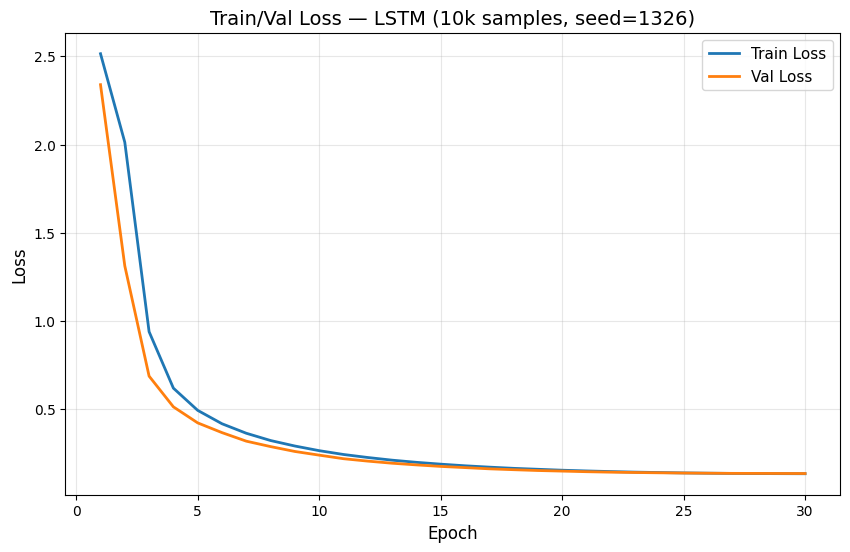

In [10]:
# ── Figure 1: Train/Val loss curves ──────────────────────────────────────
%matplotlib inline
epochs_list = [e["epoch"] for e in logger.epoch_logs]
train_losses = [e["train_loss"] for e in logger.epoch_logs]
val_losses = [e["val_loss"] for e in logger.epoch_logs]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_list, train_losses, label="Train Loss", color="tab:blue", linewidth=2)
ax.plot(epochs_list, val_losses, label="Val Loss", color="tab:orange", linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title(f"Train/Val Loss — {MODEL_TYPE.upper()} (10k samples, seed={RANDOM_SEED})", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.savefig(os.path.join(OUTPUT_DIR, "fig1_loss_curves.png"), dpi=150, bbox_inches="tight")
# plt.close(fig)
print(f"  Figure 1 saved: fig1_loss_curves.png")
plt.show()

  Figure 2 saved: fig2_sentence_accuracy.png


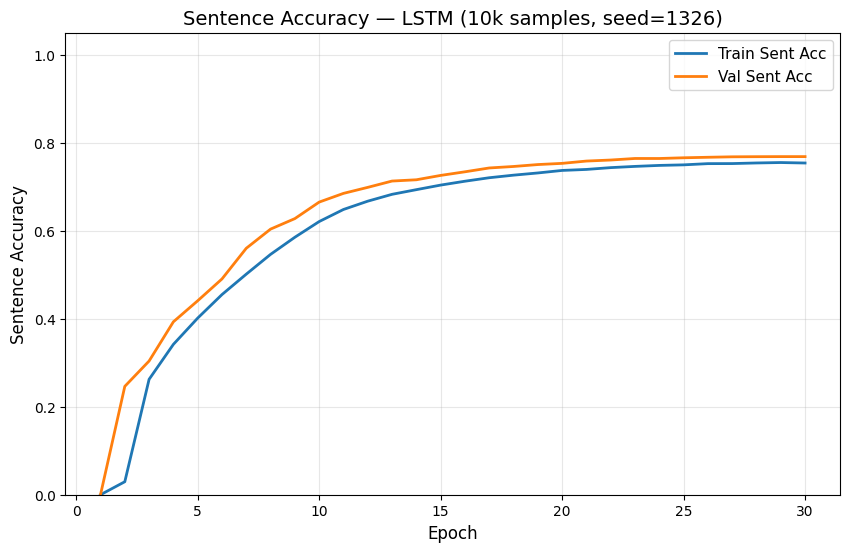

In [11]:

%matplotlib inline

# ── Figure 2: Sentence accuracy over epochs ──────────────────────────────

train_sent_accs = [e["train_sent_acc"] for e in logger.epoch_logs]
val_sent_accs = [e["val_sent_acc"] for e in logger.epoch_logs]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_list, train_sent_accs, label="Train Sent Acc", color="tab:blue", linewidth=2)
ax.plot(epochs_list, val_sent_accs, label="Val Sent Acc", color="tab:orange", linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Sentence Accuracy", fontsize=12)
ax.set_title(f"Sentence Accuracy — {MODEL_TYPE.upper()} (10k samples, seed={RANDOM_SEED})", fontsize=14)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.savefig(os.path.join(OUTPUT_DIR, "fig2_sentence_accuracy.png"), dpi=150, bbox_inches="tight")
# plt.close(fig)
print(f"  Figure 2 saved: fig2_sentence_accuracy.png")
plt.show()

  Figure 3 saved: fig3_per_coefficient_accuracy.png


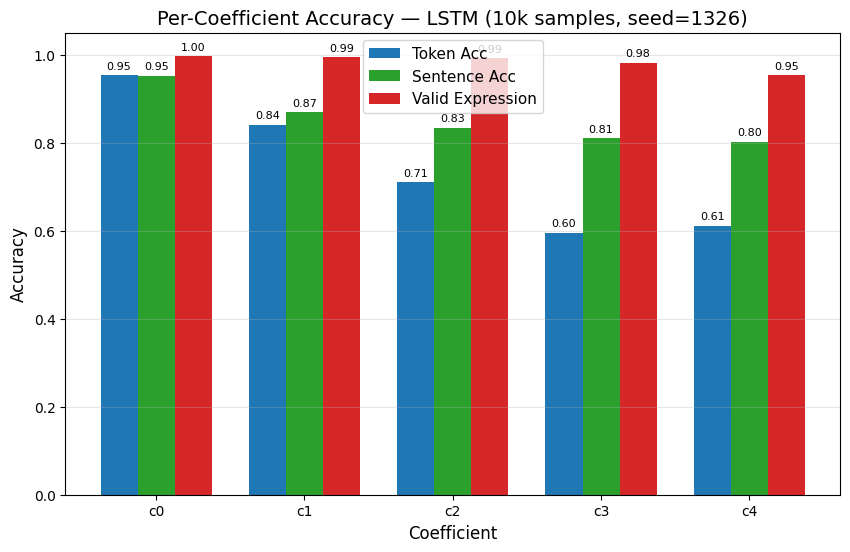

In [12]:


# ── Figure 3: Per-coefficient accuracy bar chart ─────────────────────────
%matplotlib inline

coeff_labels = [f"c{i}" for i in range(N_COEFFS)]
tok_accs = [d["token_acc"] for d in seg_metrics]
sent_accs_coeff = [d["sentence_acc"] for d in seg_metrics]
expr_valids = [d["correct_expression"] for d in seg_metrics]

x = np.arange(N_COEFFS)
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, tok_accs, width, label="Token Acc", color="tab:blue")
bars2 = ax.bar(x, sent_accs_coeff, width, label="Sentence Acc", color="tab:green")
bars3 = ax.bar(x + width, expr_valids, width, label="Valid Expression", color="tab:red")

ax.set_xlabel("Coefficient", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title(f"Per-Coefficient Accuracy — {MODEL_TYPE.upper()} (10k samples, seed={RANDOM_SEED})", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(coeff_labels)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis="y")

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0.02:
            ax.annotate(f'{height:.2f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)

fig.savefig(os.path.join(OUTPUT_DIR, "fig3_per_coefficient_accuracy.png"), dpi=150, bbox_inches="tight")
# plt.close(fig)
print(f"  Figure 3 saved: fig3_per_coefficient_accuracy.png")
plt.show()

  Figure 4 saved: fig4_token_accuracy.png


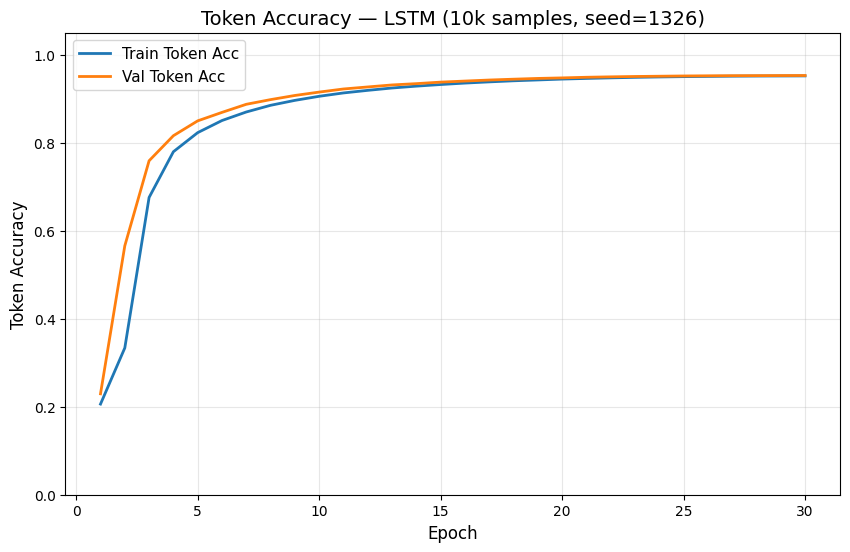

In [13]:

# ── Figure 4: Token accuracy over epochs ─────────────────────────────────

train_tok_accs = [e["train_tok_acc"] for e in logger.epoch_logs]
val_tok_accs = [e["val_tok_acc"] for e in logger.epoch_logs]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_list, train_tok_accs, label="Train Token Acc", color="tab:blue", linewidth=2)
ax.plot(epochs_list, val_tok_accs, label="Val Token Acc", color="tab:orange", linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Token Accuracy", fontsize=12)
ax.set_title(f"Token Accuracy — {MODEL_TYPE.upper()} (10k samples, seed={RANDOM_SEED})", fontsize=14)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.savefig(os.path.join(OUTPUT_DIR, "fig4_token_accuracy.png"), dpi=150, bbox_inches="tight")
# plt.close(fig)
print(f"  Figure 4 saved: fig4_token_accuracy.png")
plt.show()

  Figure 5 saved: fig5_sequence_lengths.png


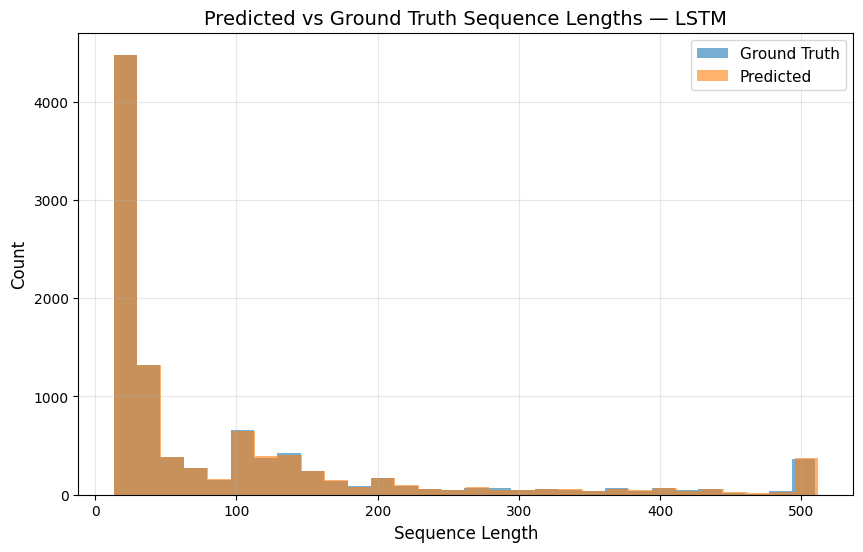

In [14]:


# ── Figure 5: Sequence length histogram ──────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(gt_lengths, bins=30, alpha=0.6, label="Ground Truth", color="tab:blue")
ax.hist(pred_lengths, bins=30, alpha=0.6, label="Predicted", color="tab:orange")
ax.set_xlabel("Sequence Length", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title(f"Predicted vs Ground Truth Sequence Lengths — {MODEL_TYPE.upper()}", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.savefig(os.path.join(OUTPUT_DIR, "fig5_sequence_lengths.png"), dpi=150, bbox_inches="tight")
# plt.close(fig)
print(f"  Figure 5 saved: fig5_sequence_lengths.png")

plt.show()

In [15]:



# ══════════════════════════════════════════════════════════════════════════════
# CUSTOM TEST FUNCTIONS EVALUATION (final, with SymPy)
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 68)
print("  Final evaluation on CUSTOM_TEST_FUNCTIONS (exact + SymPy)")
print("=" * 68)
run_custom_test_functions(model, device, logger=logger, max_gen_len=MAX_GEN_LEN)
print("=" * 68)


# ══════════════════════════════════════════════════════════════════════════════
# GENERATE REPORT
# ══════════════════════════════════════════════════════════════════════════════

logger.generate_report()
print(f"\n  Report saved to {OUTPUT_DIR}/")
print(f"  All tables and figures generated successfully.")



  Final evaluation on CUSTOM_TEST_FUNCTIONS (exact + SymPy)

  [ 1] f(x) = (x**2 + 1)*sin(x)
       c0 [exact=OK sympy=OK]  gt=a**2*sin(a) + sin(a)  pred=a**2*sin(a) + sin(a)
       c1 [exact=OK sympy=OK]  gt=a**2*cos(a) + 2*a*sin(a) + cos(a)  pred=a**2*cos(a) + 2*a*sin(a) + cos(a)
       c2 [exact=-- sympy=--]  gt=-a**2*sin(a) + 4*a*cos(a) + sin(a)  pred=-a**2*sin(a) + 4*a*cos(a) + 2*sin(a)
       c3 [exact=-- sympy=--]  gt=-a**2*cos(a) - 6*a*sin(a) + 5*cos(a)  pred=-a**2*cos(a) - 6*a*sin(a) + 6*cos(a)
       c4 [exact=-- sympy=--]  gt=a**2*sin(a) - 8*a*cos(a) - 11*sin(a)  pred=a**2*sin(a) - 8*a*cos(a) - 12*sin(a)
       => exact: 2/5  sympy: 2/5

  [ 2] f(x) = x**3*cos(2*x)
       c0 [exact=OK sympy=OK]  gt=a**3*cos(2*a)  pred=a**3*cos(2*a)
       c1 [exact=-- sympy=--]  gt=-2*a**3*sin(2*a) + 3*a**2*cos(2*a)  pred=-2*a**3*sin(2*a) + 2*a*cos(2*a)
       c2 [exact=-- sympy=--]  gt=-4*a**3*cos(2*a) - 12*a**2*sin(2*a) + 6*a*cos(2*a)  pred=-a**3*cos(2*a) - 6*a*sin(2*a) + 2*cos(2*a)
     